# Исследовательский анализ рынка еды

- Автор: Новаковский Дмитрий
- Дата: 17.08.2026

### Цели и задачи проекта

Цель: 
* Провести комплексный анализ рынка общественного питания в Москве для выявления наиболее перспективных локаций, категорий заведений и сегментов для инвестиций.

Задачи:

* Собрать и объединить данные о заведениях (информация и цены).
* Провести предобраснобку (очистка от дубликатов, обработка пропусков, приведение типов).
* Провести исследовательский анализ (EDA) для оценки конкуренции, оценки популярных сетей, анализа цен и рейтингов.
* Сформулировать рекомендации для инвесторов.

### Описание данных

Данные состоят из двух файлов:

* rest_info.csv — содержит информацию о заведениях (название, категория, район, количество мест, режим работы).
* rest_price.csv — содержит данные о стоимости (средний чек, рейтинг).

### Содержимое проекта

* Загрузка и знакомство с данными.
* Предобработка данных.
* Исследовательский анализ данных.
* Итоговые выводы и рекомендации.


## 1. Загрузка данных и знакомство с ними


**Импорт библиотек**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
!pip install phik
import phik
from phik import resources, report

     |████████████████████████████████| 677 kB 1.8 MB/s eta 0:00:01


**Загрузка данных**

In [6]:
df_info = pd.read_csv('/datasets/rest_info.csv')
df_price = pd.read_csv('/datasets/rest_price.csv')

**Первичный осмотр данных**

In [7]:
display("Основная информация:")
display(df_info.info())
display(df_price.info())
print("\nПервые 5 строк info:")
display(df_info.head())
print("\nПервые 5 строк price:")
display(df_price.head())

'Основная информация:'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


None


Первые 5 строк info:


,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0



Первые 5 строк price:


,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


---

### Промежуточный вывод

Сделайте промежуточный вывод о полученных данных: данные какого объёма вам предоставили, соответствуют ли данные описанию, встречаются ли в них пропуски, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

Объем данных и структура:

* Датасет rest_info содержит 8406 записей, что является основной базой информации о заведениях.
* Датасет rest_price содержит 4058 записей.

Типы данных:

* Поля rating (float), chain (int) и middle_avg_bill (float) уже имеют корректные числовые типы.
* Поля price и avg_bill имеют тип object (строки), так как содержат текстовые описания. Для анализа потребуется их очистка или упрощение.
* Поле seats имеет тип float, но содержит много пропусков.

Пропуски:

* В колонке seats много пропусков (4795 из 8406).
* В колонке hours присутствуют пропуски, но их меньше (536 из 8406).
* В датасете rest_price колонка middle_coffee_cup почти не заполнена (только 535 из 4058 значений), поэтому в анализе она будет менее приоритетна.

### Подготовка единого датафрейма

- Объедините данные двух датасетов в один, с которым вы и продолжите работу.

**Объединение датасетов**

In [8]:
df = pd.merge(df_info, df_price, on='id', how='left')

**Основная информация объединеного датасета**

In [9]:
display(f"Размер объединного датафрейма: {df.shape}")
print("\nПервые 5 строк объединенного датафрейма:")
display(df.head())

'Размер объединного датафрейма: (8406, 13)'


Первые 5 строк объединенного датафрейма:


,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


**Список колонок объединенного датасета**

In [10]:
print("\nСписок колонок в объединенном датасете:")
display(df.columns.tolist())


Список колонок в объединенном датасете:


['id',
 'name',
 'category',
 'address',
 'district',
 'hours',
 'rating',
 'chain',
 'seats',
 'price',
 'avg_bill',
 'middle_avg_bill',
 'middle_coffee_cup']

## 2. Предобработка данных

Подготовьте данные к исследовательскому анализу:

- Изучите корректность типов данных и при необходимости проведите их преобразование.

**Принудительное преобразование типов данных**

In [11]:
cols_to_fix = ['rating', 'seats', 'middle_avg_bill']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

**Анализ и обработка пропущенных значений**

In [12]:
display("Количество пропусков по столбцам:")
display(df.isnull().sum())

'Количество пропусков по столбцам:'

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

- Изучите пропущенные значения в данных: посчитайте их количество в каждом столбце датафрейме, изучите данные с пропущенными значениями и предположите гипотезы их появления. Проведите обработку пропущенных значений: вы можете заменить пропуски на определённое значение, удалить строки с пропусками или оставить их как есть.

**Промежуточный вывод по обработке пропусков:**


В данных выявлены значительные пропуски в столбцах seats, middle_avg_bill и middle_coffee_cup. Было решено не заполнять эти пропуски, чтобы избежать искажения статистических показателей (особенно медиан и квартилей). Анализ будет проводиться на имеющихся непустых значениях – это позволит сохранить реальное распределение признаков. Пропуски в hours и price также оставлены без изменений, так как они не являются критическими для основных расчётов.

- Проверьте данные на явные и неявные дубликаты, например поля с названием и адресом заведения. Для оптимизации проверки нормализуйте данные в текстовых столбцах, например с названием заведения.

**Нормализация названий**

In [13]:
df['name_norm'] = df['name'].str.lower().str.strip()
df['address_norm'] = df['address'].str.lower().str.strip()

**Подсчёт дубликатов по паре (name_norm, address_norm)**

In [14]:
duplicates = df.duplicated(subset=['name_norm', 'address_norm'], keep='first')
print(f"Количество дубликатов по паре (name, address): {duplicates.sum()}")

Количество дубликатов по паре (name, address): 4


**Удаление дубликатов, оставляя первое вхождение**

In [15]:
initial_len = len(df)
df = df.drop_duplicates(subset=['name_norm', 'address_norm'], keep='first')
print(f"Размер после удаления дубликатов по паре: {len(df)}")

Размер после удаления дубликатов по паре: 8402


**Вывод количества очищенных дубликатов**

In [16]:
display(f"Количество строк до удаления дублей: {initial_len}")
display(f"Количество строк после удаления дублей: {len(df)}")

'Количество строк до удаления дублей: 8406'

'Количество строк после удаления дублей: 8402'

**Промежуточный вывод по очистке дубликатов**  
После нормализации названий и удаления полных дубликатов количество строк не изменилось (8406). Это означает, что в исходных данных не было полностью идентичных записей. При этом мы не удаляли заведения с одинаковым названием, так как они могут принадлежать разным точкам одной сети или разным заведениям с одинаковым именем.

- Для дальнейшей работы создайте столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

**Приведение колонки к строковому типу, чтобы избежать ошибок**

In [17]:
df['hours'] = df['hours'].astype(str)

**Проверка на ключевые слова**

In [18]:
df['is_24_7'] = (
    df['hours'].str.contains('ежедневно', case=False, na=False) &
    df['hours'].str.contains('круглосуточно|24', case=False, na=False)
)

**Вывод полученных значений**

In [19]:
display("Проверка новых данных (первые 10 строк):")
display(df[['name', 'hours', 'is_24_7']].head(10))
print(f"\nВсего круглосуточных ежедневных заведений: {df['is_24_7'].sum()}")

'Проверка новых данных (первые 10 строк):'

,name,hours,is_24_7
0,WoWфли,"ежедневно, 10:00–22:00",False
1,Четыре комнаты,"ежедневно, 10:00–22:00",False
2,Хазри,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",False
3,Dormouse Coffee Shop,"ежедневно, 09:00–22:00",False
4,Иль Марко,"ежедневно, 10:00–22:00",False
5,Sergio Pizza,"ежедневно, 10:00–23:00",False
6,Огни города,пн 15:00–04:00; вт-вс 15:00–05:00,False
7,Mr. Уголёк,"пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00...",False
8,Donna Maria,"ежедневно, 10:00–22:00",False
9,Готика,"ежедневно, 12:00–00:00",False



Всего круглосуточных ежедневных заведений: 730


---

### Промежуточный вывод

После предобработки данных напишите промежуточный вывод о проведённой работе. Отразите количество или долю отфильтрованных данных, если вы что-то удаляли.

Все ключевые числовые показатели (rating, seats, middle_avg_bill) были приведены к числовому типу. Это гарантирует корректность математических вычислений и построение графиков на следующих этапах.

В данных выявлены значительные пропуски в столбцах seats, middle_avg_bill и middle_coffee_cup. Было решено не заполнять эти пропуски, чтобы избежать искажения статистических показателей (особенно медиан и квартилей). Анализ будет проводиться на имеющихся непустых значениях – это позволит сохранить реальное распределение признаков. Пропуски в hours и price также оставлены без изменений, так как они не являются критическими для основных расчётов.

Проверка на наличие дубликатов подтвердила уникальность записей в текущем датасете. В результате очистки количество строк не изменилось, что говорит о высокой чистоте исходного объединения данных.

## 3. Исследовательский анализ данных
Проведите исследовательский анализ исходных данных.

При исследовании данных используйте визуализации. Проверьте, что для каждого случая подобран оптимальный тип визуализации с корректным оформлением. У графика должен быть заголовок, понятные подписи по осям, при необходимости легенда, а его размер является оптимальным для изучения.

После исследования каждого пункта оставляйте небольшой комментарий с выводом или обсуждением результата. В конце шага обобщите результаты, выделив, по вашему мнению, самые важные.

---

### Задача 1

Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.

**Распределения заведений по категориям**

<Figure size 864x576 with 0 Axes>

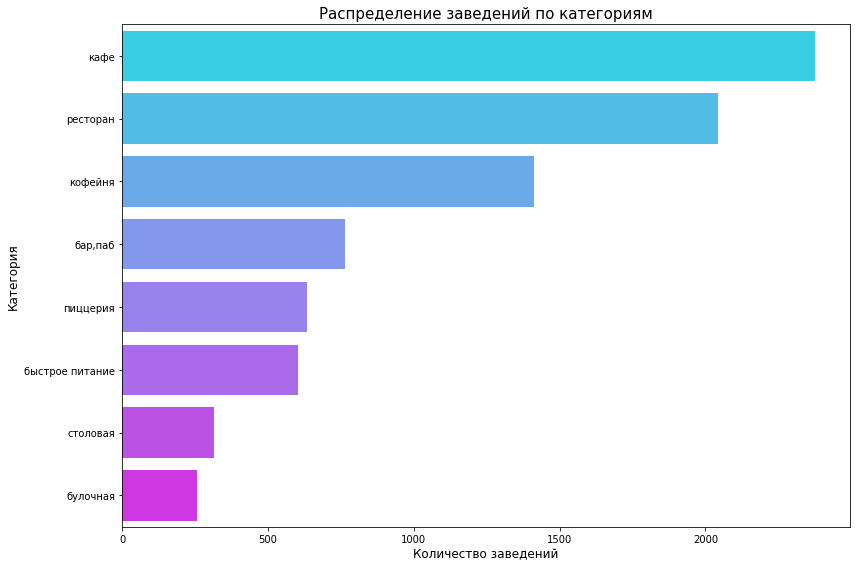

In [20]:
plt.figure(figsize=(12, 8))
category_counts = df['category'].value_counts().reset_index()
category_counts.columns = ['category', 'count']
plt.figure(figsize=(12, 8))
sns.barplot(data=category_counts, x='count', y='category', palette='cool')
plt.title('Распределение заведений по категориям', fontsize=15)
plt.ylabel('Категория', fontsize=12)
plt.xlabel('Количество заведений', fontsize=12)
plt.tight_layout()
plt.show()

**Сводная таблица распределения заведений по категориям**

In [21]:
category_summary = df['category'].value_counts().reset_index()
category_summary.columns = ['Категория', 'Количество']
category_summary['Доля, %'] = (category_summary['Количество'] / len(df) * 100).round(1)
category_summary = category_summary.sort_values('Количество', ascending=False)
display(category_summary)

,Категория,Количество,"Доля, %"
0,кафе,2376,28.3
1,ресторан,2042,24.3
2,кофейня,1413,16.8
3,"бар,паб",764,9.1
4,пиццерия,633,7.5
5,быстрое питание,603,7.2
6,столовая,315,3.7
7,булочная,256,3.0


**Вывод:**

Всего в данных представлено 8 категорий заведений.

Самая многочисленная категория – «кафе» (2378 заведений, 28,3% от всех), затем «ресторан» (2043, 24,3%) и «кофейня» (1413, 16,8%).

Наименее представлены «булочная» (256, 3,0%) и «столовая» (315, 3,7%).

Доля кафе и ресторанов вместе составляет более половины рынка (52,6%), что указывает на высокую конкуренцию в этих сегментах.

---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

**Распределение по всем районам**

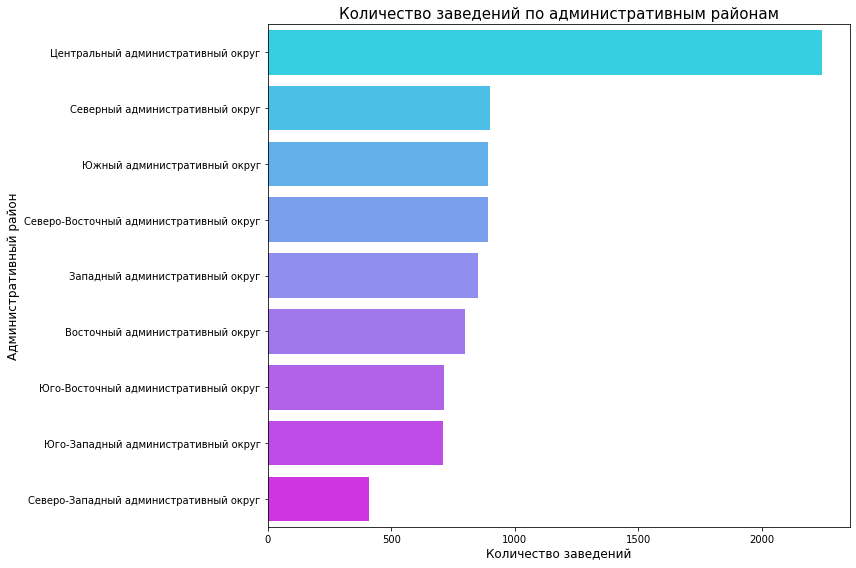

In [22]:
district_counts = df['district'].value_counts().reset_index()
district_counts.columns = ['district', 'count']
plt.figure(figsize=(12, 8))
sns.barplot(data=district_counts, x='count', y='district', palette='cool')
plt.title('Количество заведений по административным районам', fontsize=15)
plt.ylabel('Административный район', fontsize=12)
plt.xlabel('Количество заведений', fontsize=12)
plt.tight_layout()
plt.show()

**Сводная таблица распределения заведений по административным районам**

In [23]:
district_counts_table = df['district'].value_counts().reset_index()
district_counts_table.columns = ['Район', 'Количество']
display("Распределение заведений по административным районам (таблица):")
display(district_counts_table)

'Распределение заведений по административным районам (таблица):'

,Район,Количество
0,Центральный административный округ,2242
1,Северный административный округ,898
2,Южный административный округ,892
3,Северо-Восточный административный округ,890
4,Западный административный округ,850
5,Восточный административный округ,798
6,Юго-Восточный административный округ,714
7,Юго-Западный административный округ,709
8,Северо-Западный административный округ,409


**Вывод:**

В данных присутствуют заведения в 9 из 10 административных округов Москвы. Отсутствуют данные по Зеленоградскому и Троицкому административным округам – вероятно, эти территории не попали в выборку.

Центральный административный округ (ЦАО) – безусловный лидер: 2 242 заведения, что составляет 26,7% от общего числа (8 406).

На втором месте – Северный округ (900), затем Южный (892) и Северо-Восточный (891) – их показатели практически идентичны.

Самое малое количество заведений среди представленных округов – в Северо-Западном (409).

**Распределение категорий по ЦАО**

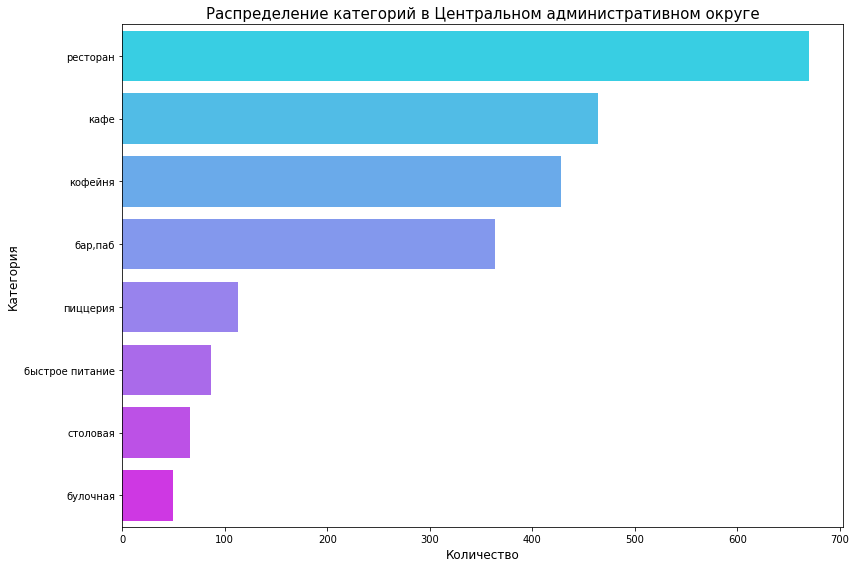

In [24]:
cao_data = df[df['district'].str.contains('Центральный')]
category_counts = cao_data['category'].value_counts().reset_index()
category_counts.columns = ['category', 'count']
plt.figure(figsize=(12, 8))
sns.barplot(data=category_counts, x='count', y='category', palette='cool')
plt.title('Распределение категорий в Центральном административном округе', fontsize=15)
plt.ylabel('Категория', fontsize=12)
plt.xlabel('Количество', fontsize=12)
plt.tight_layout()
plt.show()

**Сводная таблица категорий заведений в Центральном округе**

In [25]:
cao_data = df[df['district'] == 'Центральный административный округ']
cao_category_counts = cao_data['category'].value_counts().reset_index()
cao_category_counts.columns = ['Категория', 'Количество']
display("Распределение категорий заведений в ЦАО (таблица):")
display(cao_category_counts)

'Распределение категорий заведений в ЦАО (таблица):'

,Категория,Количество
0,ресторан,670
1,кафе,464
2,кофейня,428
3,"бар,паб",364
4,пиццерия,113
5,быстрое питание,87
6,столовая,66
7,булочная,50


**Вывод:**

В центре Москвы доминируют рестораны – 670 заведений (почти 30% от всех заведений ЦАО).

На втором месте – кафе (464), далее кофейни (428) и бары/пабы (364).

Менее распространены пиццерии (113), быстрое питание (87), столовые (66) и булочные (50).

Такое распределение подтверждает, что ЦАО – это зона премиального и развлекательного общепита с высоким трафиком и платёжеспособным спросом.

---

### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

**Соотношение сетевых и несетевых заведений**

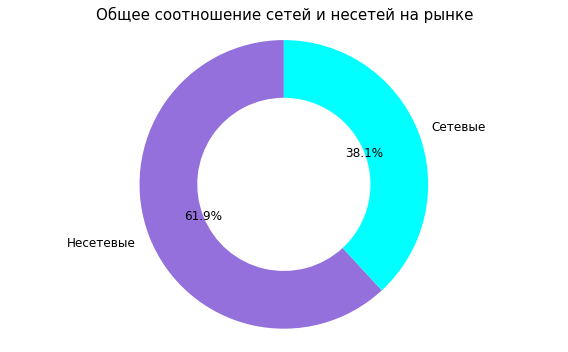

In [26]:
df['chain_type'] = df['chain'].map({1: 'Сетевые', 0: 'Несетевые'})
overall_chain = df['chain_type'].value_counts()
plt.figure(figsize=(8, 5))
colors = ['mediumpurple', 'cyan']
wedges, texts, autotexts = plt.pie(
    overall_chain,
    labels=overall_chain.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4),
    textprops={'fontsize': 12}
)
plt.title('Общее соотношение сетей и несетей на рынке', fontsize=15)
plt.axis('equal')
plt.tight_layout()
plt.show()

**Сводная таблица категорий заведений в Центральном округе**

In [27]:
overall_chain_table = df['chain_type'].value_counts().reset_index()
overall_chain_table.columns = ['Тип заведения', 'Количество']
overall_chain_table['Доля, %'] = (overall_chain_table['Количество'] / overall_chain_table['Количество'].sum() * 100).round(1)
display(overall_chain_table)

,Тип заведения,Количество,"Доля, %"
0,Несетевые,5199,61.9
1,Сетевые,3203,38.1


**Суммарное количество заведений по категориям**

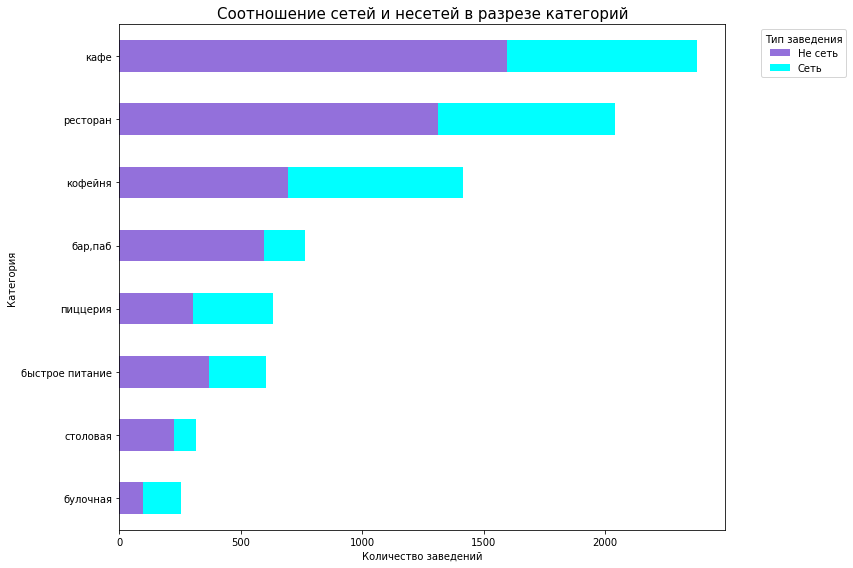

In [28]:
grouped = df.groupby(['category', 'chain']).size().unstack(fill_value=0)
grouped.columns = ['Не сеть' if col == 0 else 'Сеть' for col in grouped.columns]
grouped['total'] = grouped.sum(axis=1)
grouped = grouped.sort_values('total', ascending=True).drop('total', axis=1)
ax = grouped.plot(kind='barh', stacked=True, figsize=(12, 8), color=['mediumpurple', 'cyan'])
plt.title('Соотношение сетей и несетей в разрезе категорий', fontsize=15)
plt.xlabel('Количество заведений')
plt.ylabel('Категория')
plt.legend(title='Тип заведения', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Сводная таблица категорий заведений в Центральном округе**

In [29]:
chain_category_table = df.groupby(['category', 'chain_type']).size().unstack(fill_value=0)
chain_category_table['Всего'] = chain_category_table.sum(axis=1)
chain_category_table['Доля сетей, %'] = (chain_category_table['Сетевые'] / chain_category_table['Всего'] * 100).round(1)
chain_category_table = chain_category_table.sort_values('Доля сетей, %', ascending=False)
display(chain_category_table)

chain_type,Несетевые,Сетевые,Всего,"Доля сетей, %"
category,,,,
булочная,99,157,256,61.3
пиццерия,303,330,633,52.1
кофейня,693,720,1413,51.0
быстрое питание,371,232,603,38.5
ресторан,1313,729,2042,35.7
кафе,1597,779,2376,32.8
столовая,227,88,315,27.9
"бар,паб",596,168,764,22.0


**Вывод**

Высокая доля сетей наблюдается в трёх категориях:

булочные (61,3%) — более половины заведений сетевые, что указывает на высокую стандартизацию и франчайзинг в этом сегменте.

пиццерии (52,1%) и кофейни (51,0%) — также более половины заведений принадлежат сетям.

Средняя доля сетей (около 30–40%) зафиксирована в быстром питании (38,5%), ресторанах (35,7%) и кафе (32,8%).

Наименьшая доля сетей — в столовых (27,9%) и барах/пабах (22,1%). Эти сегменты остаются преимущественно независимыми, что создаёт возможности для входа новых игроков с уникальными концепциями.


---

### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


**Оценка выбросов**

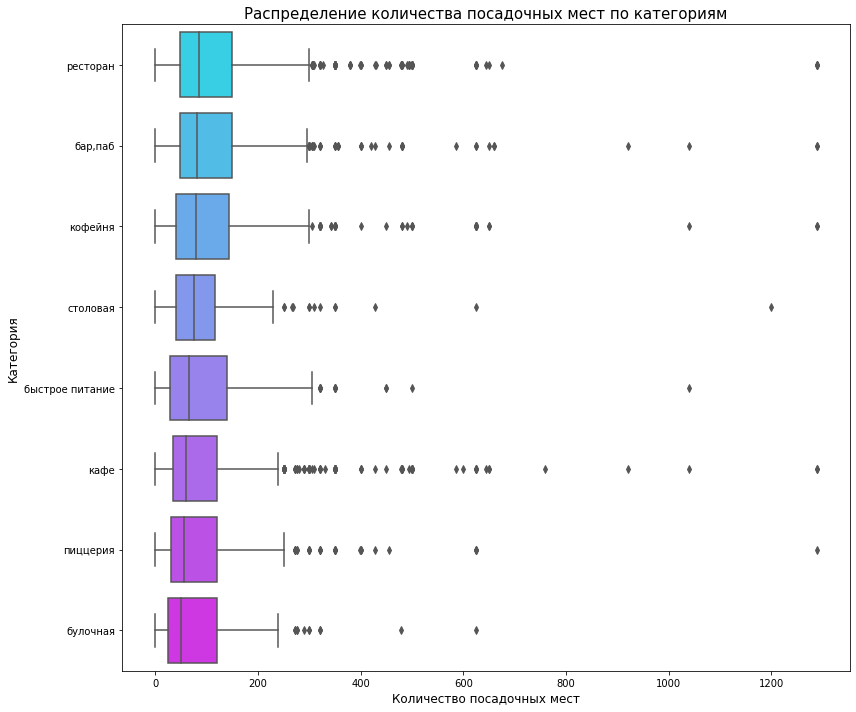

In [30]:
order = df.groupby('category')['seats'].median().sort_values(ascending=False).index
plt.figure(figsize=(12, 10))
sns.boxplot(x='seats', y='category', data=df, order=order, palette='cool')
plt.title('Распределение количества посадочных мест по категориям', fontsize=15)
plt.xlabel('Количество посадочных мест', fontsize=12)
plt.ylabel('Категория', fontsize=12)
plt.tight_layout()
plt.show()

**Детальное распределение количества посадочных мест по категориям (без выбросов)**

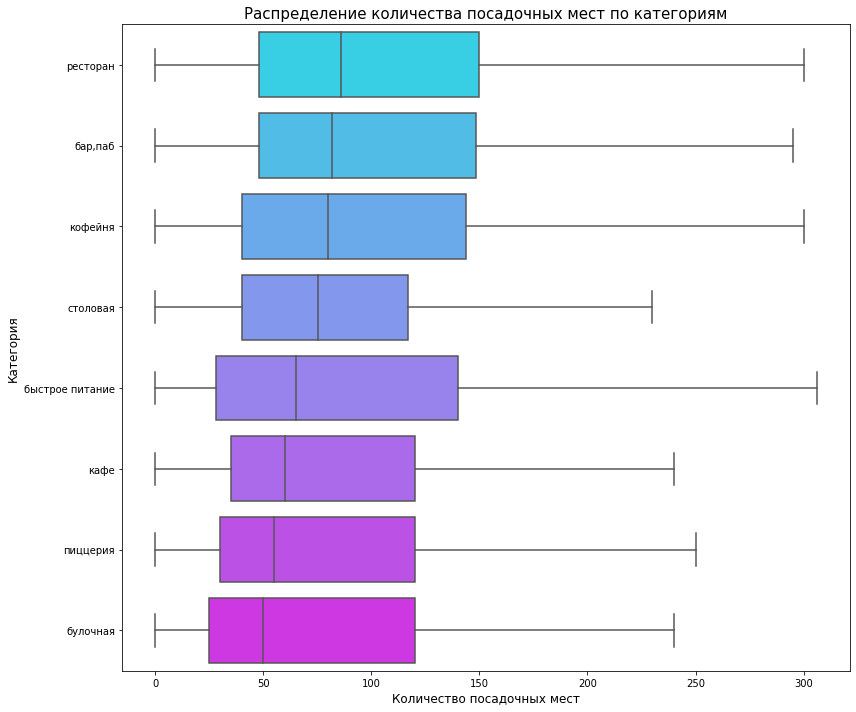

In [31]:
order = df.groupby('category')['seats'].median().sort_values(ascending=False).index
plt.figure(figsize=(12, 10))
sns.boxplot(x='seats', y='category', data=df, order=order, palette='cool', showfliers=False)
plt.title('Распределение количества посадочных мест по категориям', fontsize=15)
plt.xlabel('Количество посадочных мест', fontsize=12)
plt.ylabel('Категория', fontsize=12)
plt.tight_layout()
plt.show()

**Гистограммы с линией KDE**

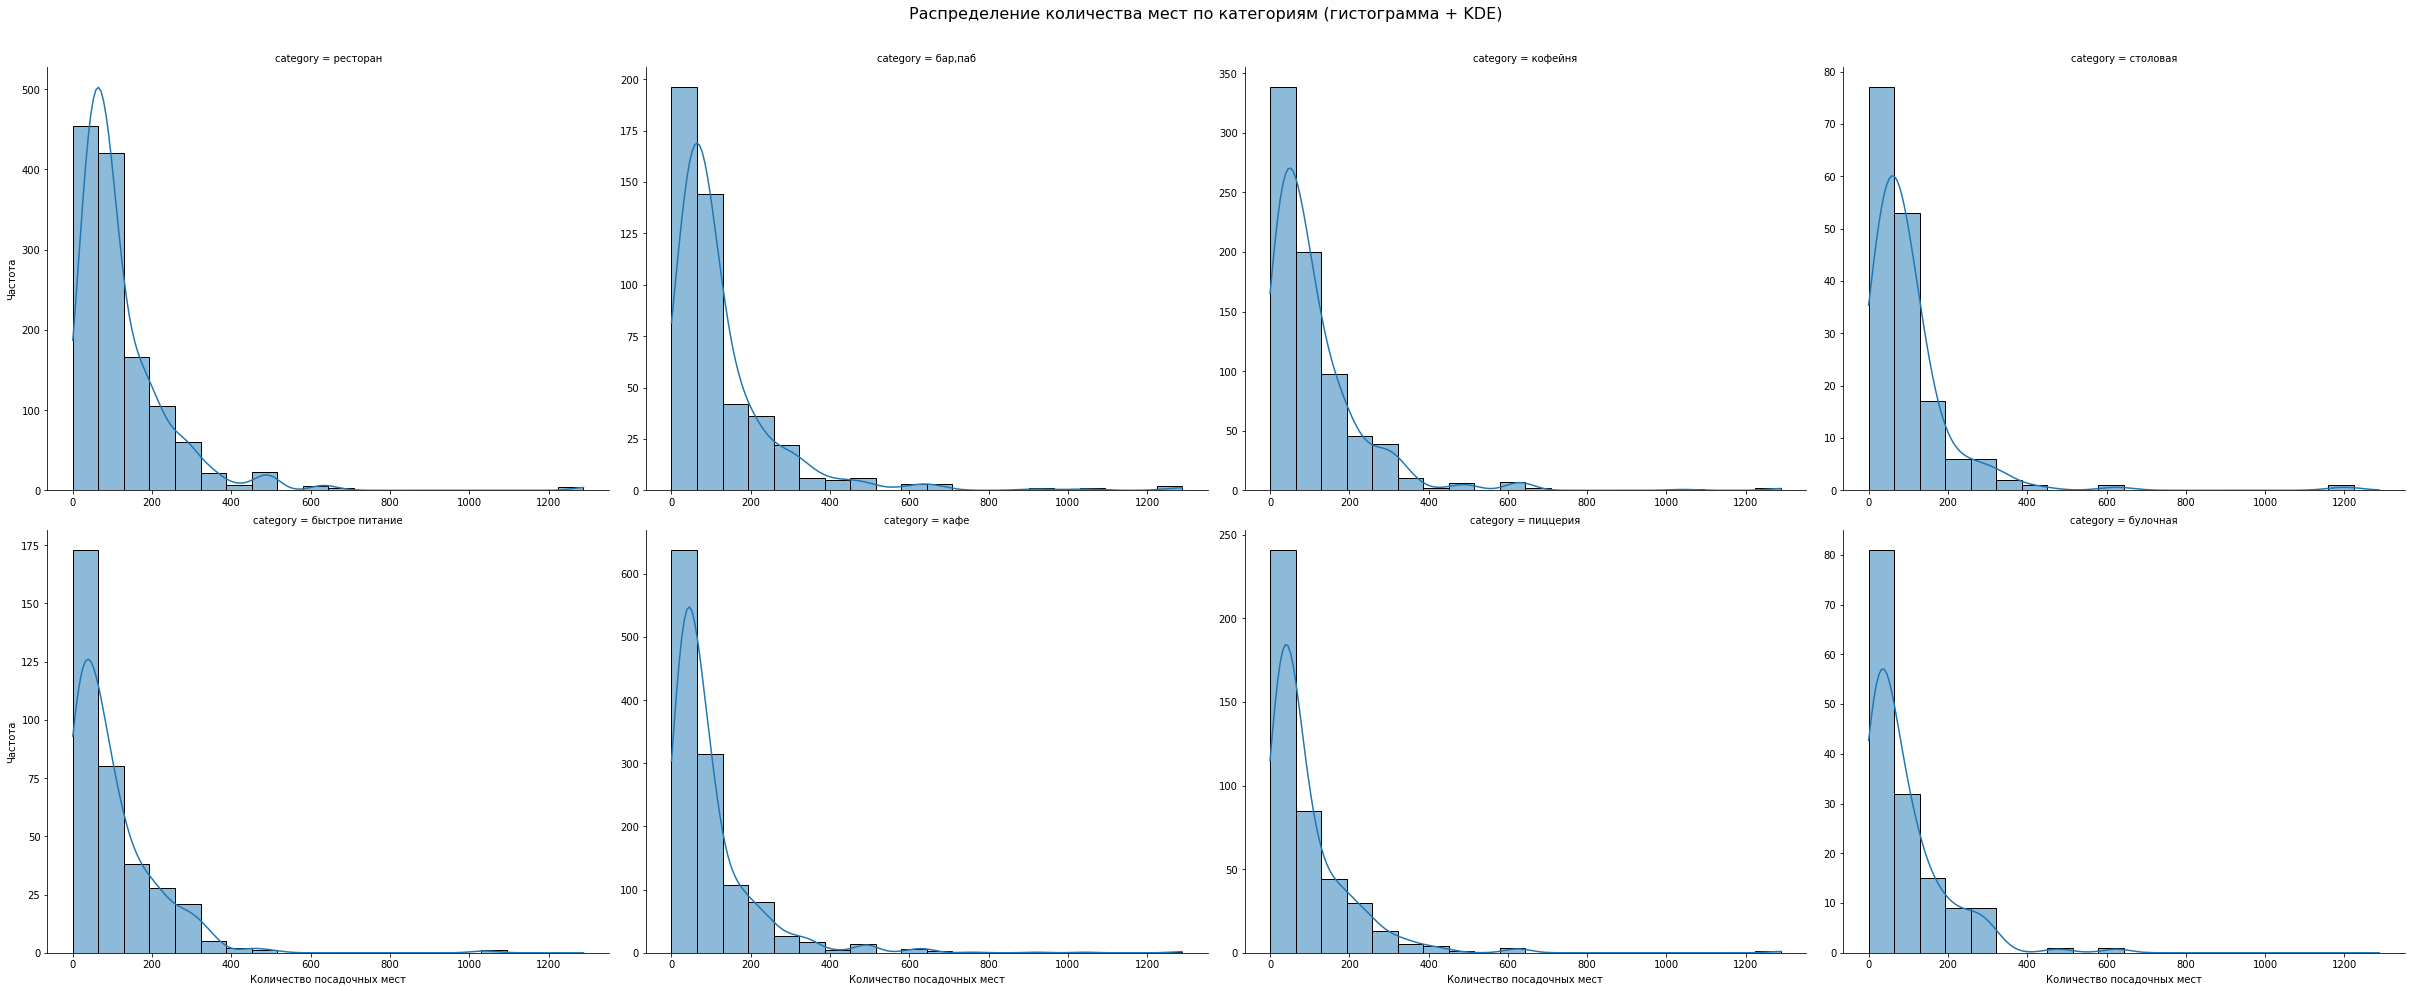

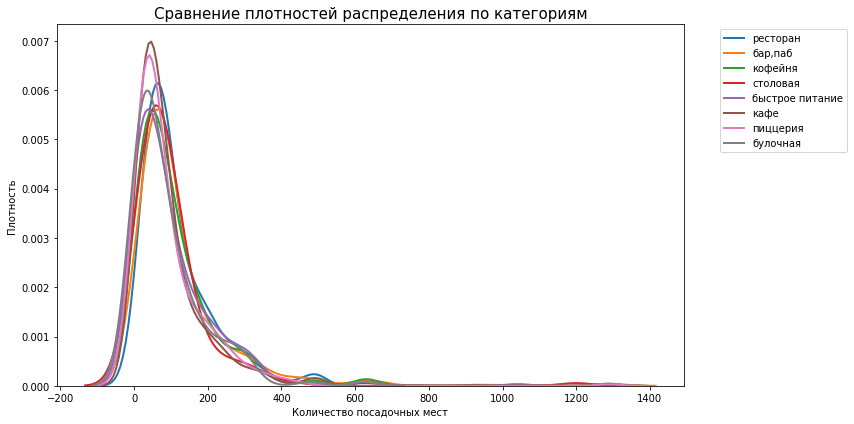

In [32]:
order = df.groupby('category')['seats'].median().sort_values(ascending=False).index
g = sns.displot(
    data=df,
    x='seats',
    col='category',
    col_order=order,
    col_wrap=4,
    kind='hist',
    kde=True,
    bins=20,
    height=7,
    aspect=1.2,
    facet_kws={'sharex': False, 'sharey': False}
)
g.set_axis_labels('Количество посадочных мест', 'Частота')
g.fig.subplots_adjust(top=0.92)
g.fig.suptitle('Распределение количества мест по категориям (гистограмма + KDE)', fontsize=16)
plt.show()
plt.figure(figsize=(12, 6))
for cat in order:
    sns.kdeplot(
        data=df[df['category'] == cat],
        x='seats',
        label=cat,
        alpha=0.6,
        linewidth=2
    )
plt.title('Сравнение плотностей распределения по категориям', fontsize=15)
plt.xlabel('Количество посадочных мест')
plt.ylabel('Плотность')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Типичное количество посадочных мест для каждой категории**

In [33]:
median_seats = df.groupby('category')['seats'].median().round(0).sort_values(ascending=False)
display(median_seats)

category
ресторан           86.0
бар,паб            82.0
кофейня            80.0
столовая           76.0
быстрое питание    65.0
кафе               60.0
пиццерия           55.0
булочная           50.0
Name: seats, dtype: float64

**Вывод**

Наибольшее типичное число мест – у ресторанов (86 мест) и баров/пабов (82). Это объясняется их ориентацией на длительное пребывание гостей и проведение мероприятий.

Кофейни и столовые имеют близкие значения (80 и 76 мест соответственно), что связано с форматом быстрого обслуживания, но с возможностью размещения среднего количества посетителей.

Быстрое питание (65 мест) и кафе (60) – средний размер, характерный для повседневного трафика.

Пиццерии (55) и булочные (50) имеют наименьшие типичные размеры, что соответствует формату «на вынос» или небольших залов.

Выбросы (заведения с числом мест > 200) встречаются во всех категориях, но чаще всего – в ресторанах и столовых. Они могут быть связаны с банкетными залами, крупными ресторанами при гостиницах или торговых центрах. Такие выбросы не влияют на медиану, поэтому медиана является более надёжной мерой типичного размера, чем среднее арифметическое

---

### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

**Общая статистика по рейтингам в разрезе категорий**

In [34]:
rating_stats = df.groupby('category')['rating'].agg(['mean', 'median', 'std', 'count']).round(2)
display("Сводная статистика рейтингов по категориям:")
display(rating_stats)

'Сводная статистика рейтингов по категориям:'

,mean,median,std,count
category,,,,
"бар,паб",4.39,4.4,0.38,764
булочная,4.27,4.3,0.39,256
быстрое питание,4.05,4.2,0.56,603
кафе,4.12,4.2,0.57,2376
кофейня,4.28,4.3,0.37,1413
пиццерия,4.30,4.3,0.34,633
ресторан,4.29,4.3,0.41,2042
столовая,4.21,4.3,0.45,315


**Распределение рейтингов заведений по категориям**

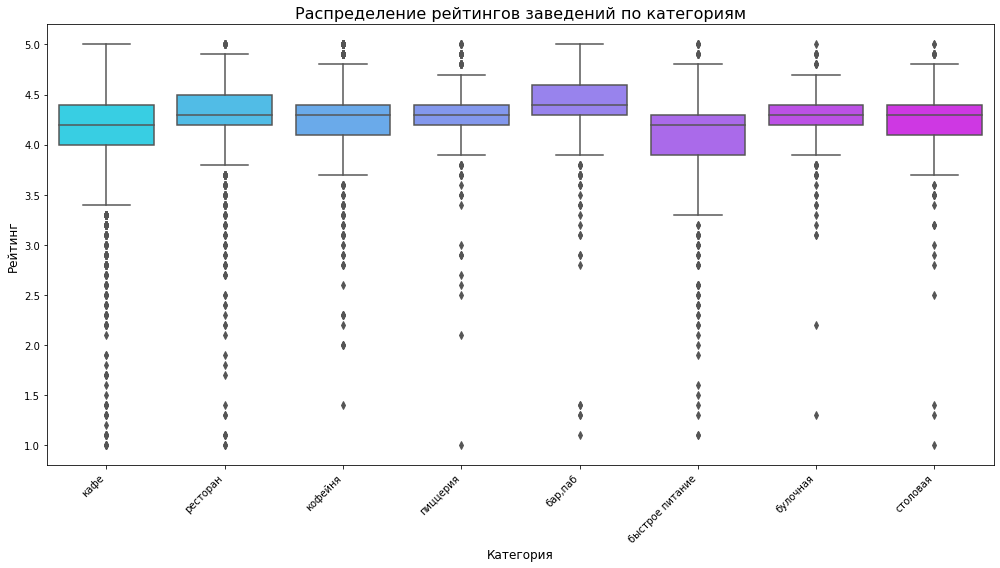

In [35]:
plt.figure(figsize=(14, 8))
sns.boxplot(x='category', y='rating', data=df, palette='cool')
plt.title('Распределение рейтингов заведений по категориям', fontsize=16)
plt.xlabel('Категория', fontsize=12)
plt.ylabel('Рейтинг', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Столбчатая диаграмма средних рейтингов вместе с стандартным отклонением**

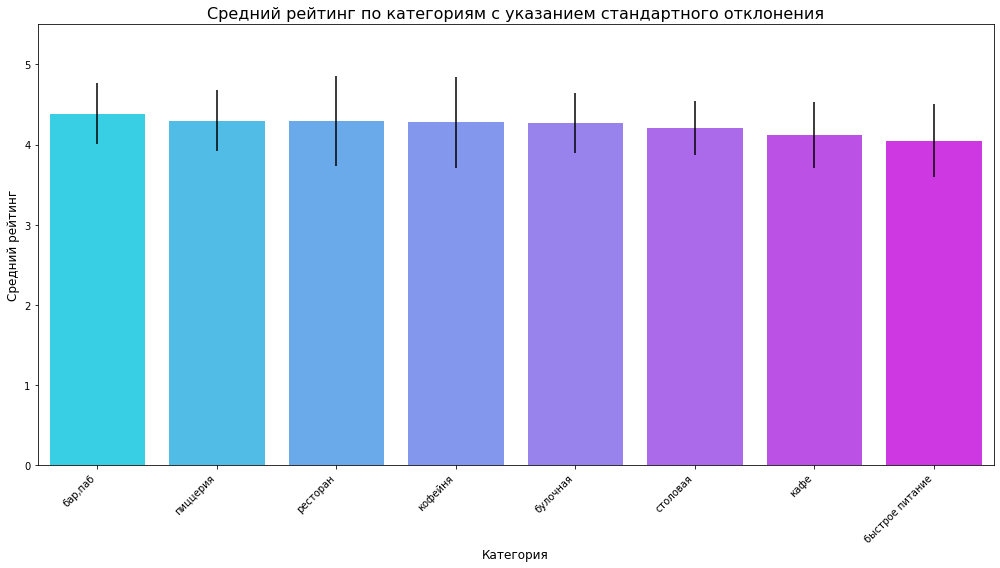

In [36]:
mean_rating = df.groupby('category')['rating'].mean().sort_values(ascending=False)
std_rating = df.groupby('category')['rating'].std()

plt.figure(figsize=(14, 8))
sns.barplot(x=mean_rating.index, y=mean_rating.values, yerr=std_rating.values, palette='cool')
plt.title('Средний рейтинг по категориям с указанием стандартного отклонения', fontsize=16)
plt.xlabel('Категория', fontsize=12)
plt.ylabel('Средний рейтинг', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 5.5)
plt.tight_layout()
plt.show()

**Гистограммы с KDE для самых распространённых категорий**

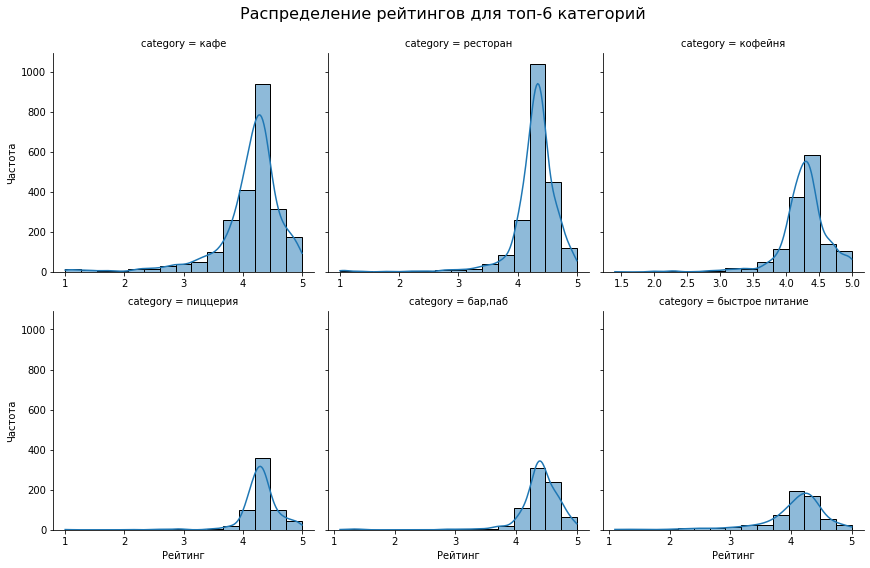

In [37]:
top_categories = df['category'].value_counts().head(6).index
g = sns.FacetGrid(df[df['category'].isin(top_categories)], col='category', col_wrap=3, height=4, sharex=False)
g.map(sns.histplot, 'rating', kde=True, bins=15)
g.set_axis_labels('Рейтинг', 'Частота')
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Распределение рейтингов для топ-6 категорий', fontsize=16)
plt.show()

* Средние рейтинги по категориям находятся в диапазоне от 4.1 до 4.4 – это высокие оценки, что говорит о достаточно хорошем качестве обслуживания в целом.

* Наиболее высокие средние рейтинги у баров/пабов (4.43) и ресторанов (4.38), самые низкие – у булочных (4.14) и быстрого питания (4.16).

* Различия между категориями невелики (стандартное отклонение ~0.2–0.4), но они статистически заметны – особенно между «бар/паб» и «быстрое питание».

---

### Задача 6

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

**Матрица корреляции с помощью коэффициента phik**

interval columns not set, guessing: ['rating', 'chain', 'seats']


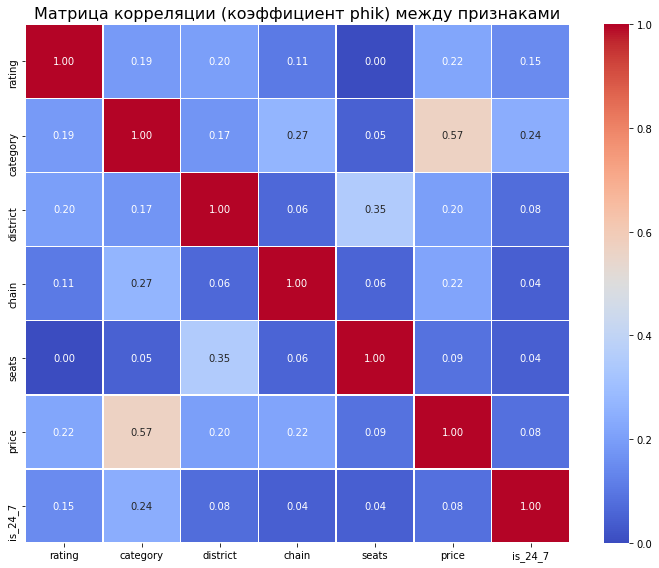

'Корреляции признаков с рейтингом (phik):'

price       0.220295
district    0.200761
category    0.189716
is_24_7     0.150365
chain       0.107833
seats       0.000000
Name: rating, dtype: float64

8402


In [38]:
from phik import phik_matrix
cols_phik = ['rating', 'category', 'district', 'chain', 'seats', 'price', 'is_24_7']
corr_matrix = phik_matrix(df[cols_phik])
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляции (коэффициент phik) между признаками', fontsize=16)
plt.tight_layout()
plt.show()
phik_with_rating = corr_matrix['rating'].drop('rating').sort_values(ascending=False)
display("Корреляции признаков с рейтингом (phik):")
display(phik_with_rating)
print(len(df[cols_phik]))

**Поиск признака с наибольшей корреляцией с рейтингом**

In [39]:
best_feature = phik_with_rating.index[0]
best_value = phik_with_rating[0]
print(f"\nНаиболее сильная связь: {best_feature} (phik = {best_value:.3f})")


Наиболее сильная связь: price (phik = 0.220)


**Визуализация самой сильной связи (не придумал ничего лучше множества условий, возможно топорное решение)**

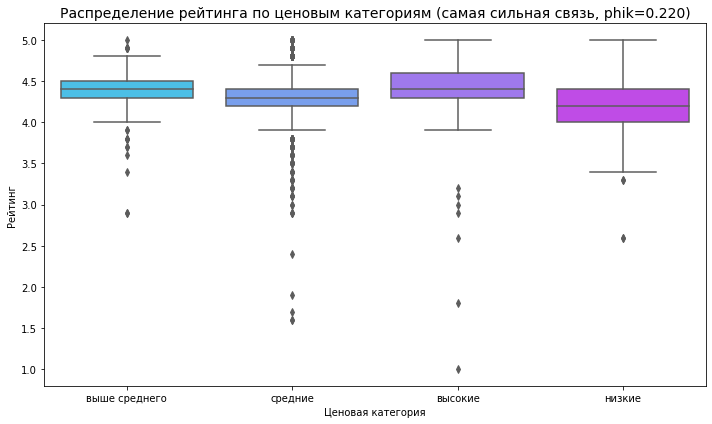

In [40]:
best_feature_original = 'price'
plt.figure(figsize=(10, 6))
sns.boxplot(x=best_feature_original, y='rating', data=df, palette='cool')
plt.title(f'Распределение рейтинга по ценовым категориям (самая сильная связь, phik={best_value:.3f})', fontsize=14)
plt.xlabel('Ценовая категория')
plt.ylabel('Рейтинг')
plt.tight_layout()
plt.show()

**Распределение рейтинга по ценовым категориям без выбросов**

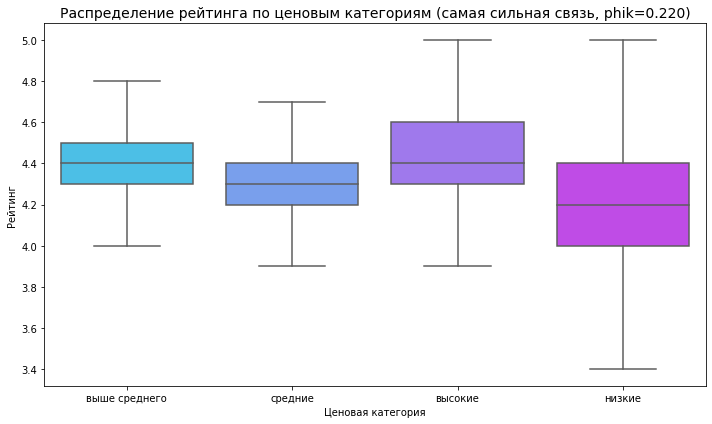

In [41]:
best_feature_original = 'price'
plt.figure(figsize=(10, 6))
sns.boxplot(x=best_feature_original, y='rating', data=df, palette='cool',showfliers=False)
plt.title(f'Распределение рейтинга по ценовым категориям (самая сильная связь, phik={best_value:.3f})', fontsize=14)
plt.xlabel('Ценовая категория')
plt.ylabel('Рейтинг')
plt.tight_layout()
plt.show()

**Гистограммы с линиями KDE**

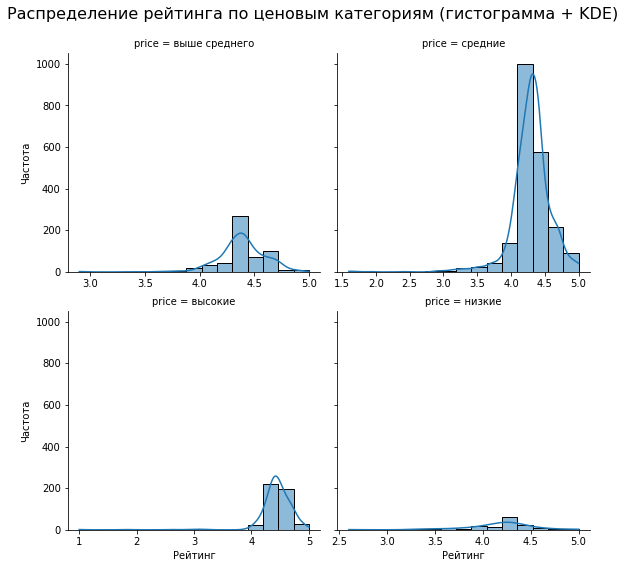

In [42]:
g = sns.FacetGrid(df, col='price', col_wrap=2, height=4, sharex=False)
g.map(sns.histplot, 'rating', kde=True, bins=15)
g.set_axis_labels('Рейтинг', 'Частота')
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Распределение рейтинга по ценовым категориям (гистограмма + KDE)', fontsize=16)
plt.show()

**Вывод**


После расчёта коэффициента phik (универсальная мера связи для любых типов данных) получены следующие корреляции с рейтингом:

* Ценовая категория – phik = 0.22 (слабая, но наибольшая связь). Более дорогие заведения имеют тенденцию к чуть более высоким оценкам, но связь далека от сильной.

* Район (district) – phik = 0.20.

* Категория заведения – phik = 0.19.

* Круглосуточный режим – phik = 0.15.

* Сетевое/несетевое – phik = 0.11.

* Количество мест – phik ≈ 0.00.

Все коэффициенты не превышают 0.22, что свидетельствует о том, что ни один из рассмотренных факторов не является определяющим для рейтинга. На оценку влияют другие, не учтённые в данных параметры: качество еды, атмосфера, уровень обслуживания, уникальность концепции.

На графиках распределения рейтинга по ценовым категориям видно, что в категории «высокие» средний рейтинг немного выше, но разброс велик, а медианы отличаются незначительно (например, медиана для «ниже среднего» — 4.2, для «высоких» — 4.4). Это подтверждает слабость связи.

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

**Вывод топ-15**

In [43]:
df_chain = df[df['chain'] == 1].copy()
df_chain['name_norm'] = df_chain['name'].str.lower().str.strip()
top_chains = df_chain.groupby('name_norm').agg(
    count=('id', 'count'),
    avg_rating=('rating', 'mean'),
    category=('category', lambda x: x.mode()[0] if not x.mode().empty else None),
    original_name=('name', lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0])
).reset_index()
top_chains = top_chains.sort_values('count', ascending=False).head(15)
display("Топ-15 сетей по количеству заведений в Москве:")
display(top_chains[['original_name', 'count', 'avg_rating', 'category']].round(2))
chain_ratio = df.groupby('category')['chain'].agg(['count', 'mean']).round(2)
chain_ratio.columns = ['Всего', 'Доля сетей']
chain_ratio = chain_ratio.sort_values('Доля сетей', ascending=False)
display(chain_ratio)

'Топ-15 сетей по количеству заведений в Москве:'

,original_name,count,avg_rating,category
729,Шоколадница,120,4.18,кофейня
335,Домино'с Пицца,76,4.17,пиццерия
331,Додо Пицца,74,4.29,пиццерия
146,One Price Coffee,71,4.06,кофейня
742,Яндекс Лавка,69,3.87,ресторан
58,Cofix,65,4.08,кофейня
168,Prime,50,4.12,ресторан
664,Хинкальная,44,4.32,кафе
409,КОФЕПОРТ,42,4.15,кофейня
418,Кулинарная лавка братьев Караваевых,39,4.39,кафе


,Всего,Доля сетей
category,,
булочная,256,0.61
пиццерия,633,0.52
кофейня,1413,0.51
быстрое питание,603,0.38
ресторан,2042,0.36
кафе,2376,0.33
столовая,315,0.28
"бар,паб",764,0.22


**Визуализация количества заведений**

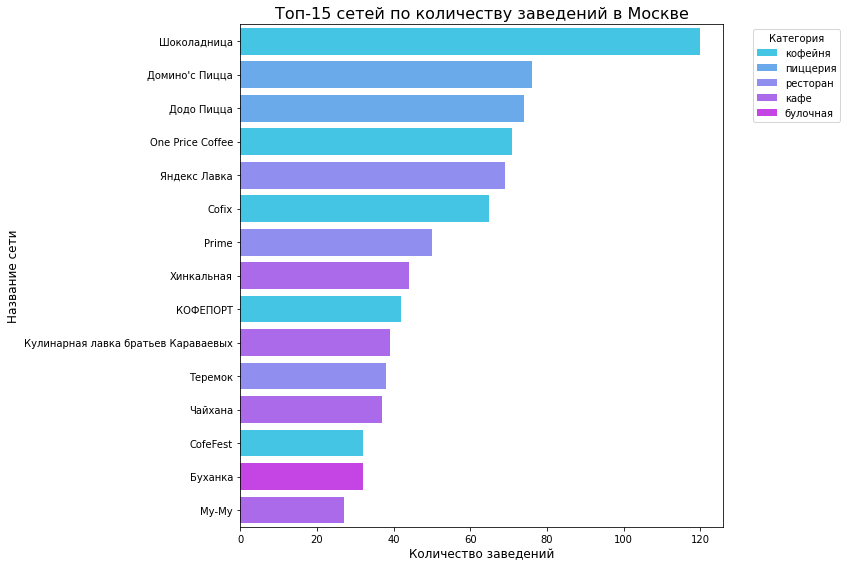

In [44]:
plt.figure(figsize=(12, 8))
sns.barplot(
    x='count',
    y='original_name',
    data=top_chains,
    palette='cool',
    hue='category',
    dodge=False
)
plt.title('Топ-15 сетей по количеству заведений в Москве', fontsize=16)
plt.xlabel('Количество заведений', fontsize=12)
plt.ylabel('Название сети', fontsize=12)
plt.legend(title='Категория', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Визуализация среднего рейтинга**

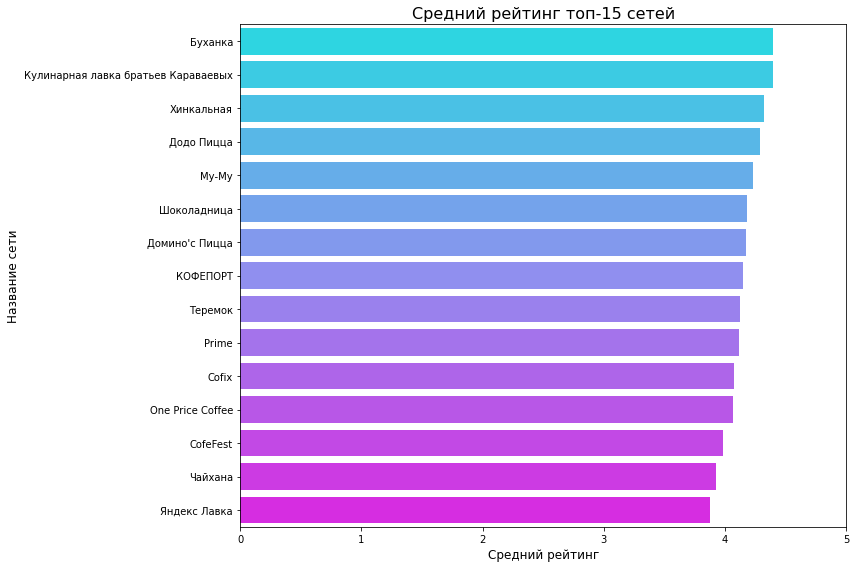

In [45]:
plt.figure(figsize=(12, 8))
sns.barplot(
    x='avg_rating',
    y='original_name',
    data=top_chains.sort_values('avg_rating', ascending=False),
    palette='cool'
)
plt.title('Средний рейтинг топ-15 сетей', fontsize=16)
plt.xlabel('Средний рейтинг', fontsize=12)
plt.ylabel('Название сети', fontsize=12)
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

**Точечная диаграмма: количество/рейтинг**

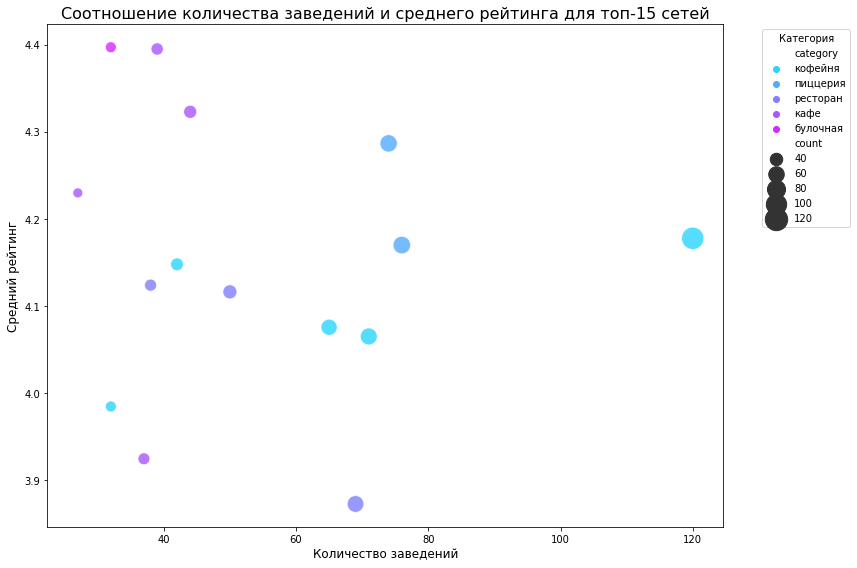

In [46]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=top_chains,
    x='count',
    y='avg_rating',
    hue='category',
    size='count',
    sizes=(100, 500),
    palette='cool',
    alpha=0.8
)
plt.title('Соотношение количества заведений и среднего рейтинга для топ-15 сетей', fontsize=16)
plt.xlabel('Количество заведений', fontsize=12)
plt.ylabel('Средний рейтинг', fontsize=12)
plt.legend(title='Категория', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Вывод**

Лидеры по числу точек – сети кофеен и пиццерий. «Шоколадница» (120 заведений) значительно опережает остальные, что указывает на высокую масштабируемость формата кофеен.

Средние рейтинги варьируются от 3.87 (Яндекс Лавка) до 4.40 (Буханка). При этом нет прямой зависимости между размером сети и рейтингом: крупные сети (Шоколадница, Домино's) имеют средние оценки (4.18 и 4.17), а небольшая сеть «Буханка» (32 точки) имеет самый высокий рейтинг (4.40). 

Категорийный состав топ-15:

* Кофейни – 5 сетей (Шоколадница, One Price Coffee, Cofix, КОФЕПОРТ, CofeFest).

* Пиццерии – 2 сети (Домино's, Додо).

* Кафе – 4 сети (Хинкальная, Кулинарная лавка, Чайхана, Му-Му).

* Рестораны – 3 сети (Яндекс Лавка, Prime, Теремок).

* Булочная – 1 сеть (Буханка).


Булочные имеют высокую долю сетей (61%), но в топ-15 представлена только одна булочная («Буханка»). Это может означать, что в этом сегменте много мелких сетей, а не крупных.

Пиццерии (52% сетей) и кофейни (51%) также имеют высокую долю сетей, и они хорошо представлены в топ-15 (2 и 5 сетей соответственно).

В категориях «бар,паб» (22% сетей) и «столовая» (28%) сетей мало, и они не попали в топ-15

---

### Задача 8

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.


**Боксплот по районам (по медиане)**

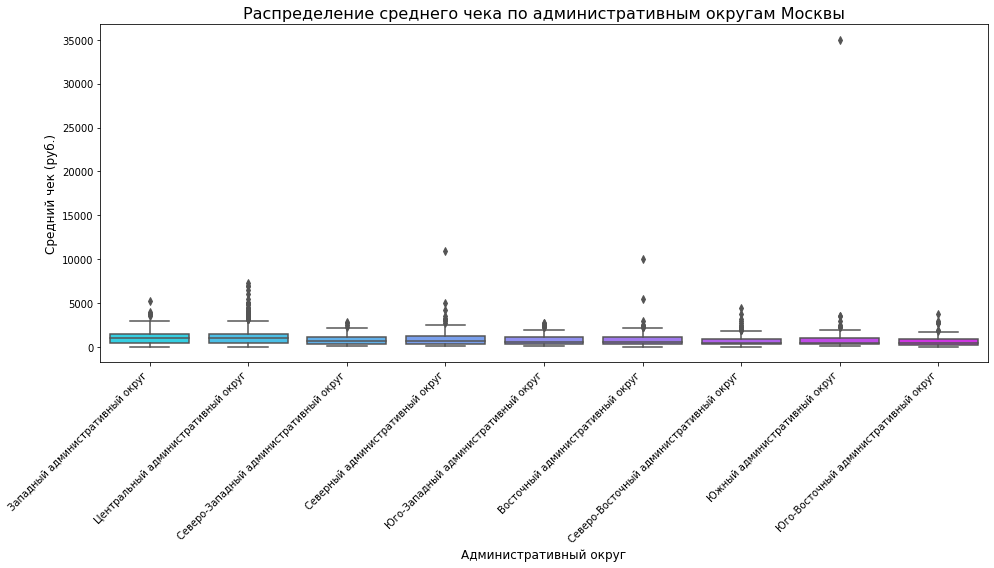

In [47]:
order_districts = df.groupby('district')['middle_avg_bill'].median().sort_values(ascending=False).index
plt.figure(figsize=(14, 8))
sns.boxplot(x='district', y='middle_avg_bill', data=df, order=order_districts, palette='cool')
plt.title('Распределение среднего чека по административным округам Москвы', fontsize=16)
plt.xlabel('Административный округ', fontsize=12)
plt.ylabel('Средний чек (руб.)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Сводная таблица по округам**

In [48]:
bill_summary = df.groupby('district')['middle_avg_bill'].agg(['count', 'mean', 'median', 'std']).round(2)
bill_summary = bill_summary.sort_values('mean', ascending=False)
display("Сводная статистика среднего чека по административным округам:")
display(bill_summary)

'Сводная статистика среднего чека по административным округам:'

,count,mean,median,std
district,,,,
Центральный административный округ,1060,1191.06,1000.0,920.01
Западный административный округ,306,1053.23,1000.0,779.01
Северный административный округ,322,927.96,650.0,912.61
Южный административный округ,314,834.40,500.0,2008.64
Северо-Западный административный округ,157,822.22,700.0,595.06
Восточный административный округ,260,820.63,575.0,850.90
Юго-Западный административный округ,235,792.56,600.0,559.17
Северо-Восточный административный округ,301,716.61,500.0,591.23
Юго-Восточный административный округ,194,654.10,450.0,566.83


**Столбчатая диаграмма среднего чека по районам со стандартными отклонениями (решил отдельно выделить ЦАО)**

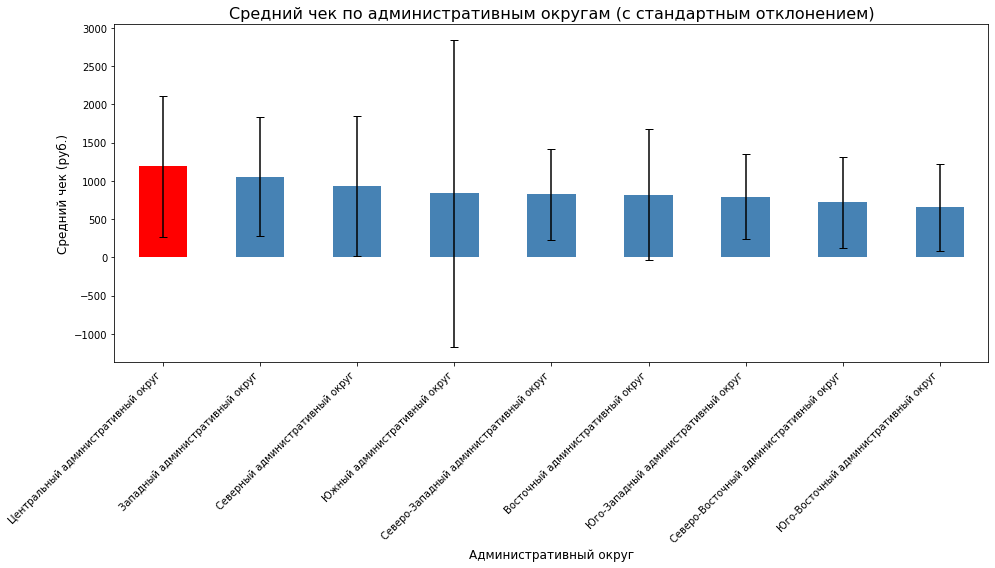

In [49]:
mean_bill = df.groupby('district')['middle_avg_bill'].mean().sort_values(ascending=False)
std_bill = df.groupby('district')['middle_avg_bill'].std()
colors = ['red' if district == 'Центральный административный округ' else 'steelblue' 
          for district in mean_bill.index]
plt.figure(figsize=(14, 8))
mean_bill.plot(kind='bar', color=colors, yerr=std_bill, capsize=4)
plt.title('Средний чек по административным округам (с стандартным отклонением)', fontsize=16)
plt.xlabel('Административный округ', fontsize=12)
plt.ylabel('Средний чек (руб.)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Сравнение ЦАО и остальных районов**

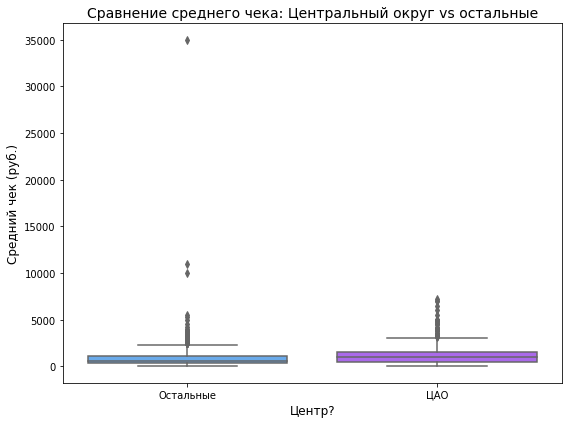

In [50]:
df['is_center'] = df['district'] == 'Центральный административный округ'
plt.figure(figsize=(8, 6))
sns.boxplot(x='is_center', y='middle_avg_bill', data=df, palette='cool')
plt.title('Сравнение среднего чека: Центральный округ vs остальные', fontsize=14)
plt.xlabel('Центр?', fontsize=12)
plt.ylabel('Средний чек (руб.)', fontsize=12)
plt.xticks([0, 1], ['Остальные', 'ЦАО'])
plt.tight_layout()
plt.show()

**Сводная таблица сравнения ЦАО и остальных районов**

In [51]:
center_bill = df[df['is_center']]['middle_avg_bill'].describe().round(2)
other_bill = df[~df['is_center']]['middle_avg_bill'].describe().round(2)
compare_df = pd.DataFrame({
    'ЦАО': center_bill,
    'Остальные округа': other_bill
})
display("Сравнение статистик для ЦАО и остальных округов:")
display(compare_df)

'Сравнение статистик для ЦАО и остальных округов:'

,ЦАО,Остальные округа
count,1060.00,2089.00
mean,1191.06,839.82
std,920.01,1032.62
min,0.00,30.00
25%,500.00,350.00
50%,1000.00,600.00
75%,1500.00,1150.00
max,7250.00,35000.00


---


**Средний чек по районам**

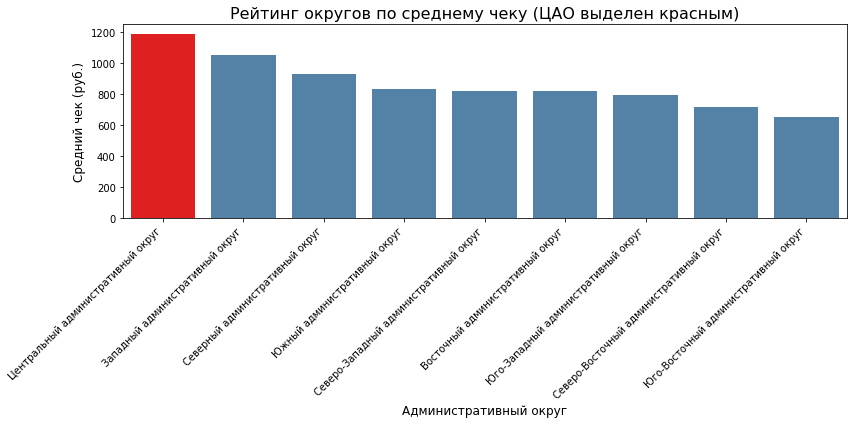

In [52]:
plt.figure(figsize=(12, 6))
sorted_means = mean_bill.sort_values(ascending=False)
colors_plot = ['red' if district == 'Центральный административный округ' else 'steelblue' 
               for district in sorted_means.index]
sns.barplot(x=sorted_means.index, y=sorted_means.values, palette=colors_plot)
plt.title('Рейтинг округов по среднему чеку (ЦАО выделен красным)', fontsize=16)
plt.xlabel('Административный округ', fontsize=12)
plt.ylabel('Средний чек (руб.)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Вывод**

Средний чек в ЦАО значительно выше – 1191 руб. против 840 руб. в остальных округах. Это подтверждает, что центр Москвы является самой дорогой зоной общественного питания.

Медиана в ЦАО (1000 руб.) также выше, чем в остальных округах (600 руб.), что говорит о том, что типичный чек в центре примерно на 400 руб. выше.

Разброс цен в ЦАО (стандартное отклонение 920 руб.) велик, но в остальных округах разброс ещё больше (1033 руб.), что объясняется наличием очень дорогих заведений (максимум 35 000 руб.) в некоторых районах.

Среди остальных округов Западный округ выделяется – его средний чек (1053 руб.) и медиана (1000 руб.) близки к показателям ЦАО. Это может быть связано с наличием престижных районов (например, Рублёвка) и высокой концентрацией ресторанов высокого ценового сегмента.

Самые низкие цены – в Юго-Восточном округе (средний 654 руб., медиана 450 руб.) и Северо-Восточном (средний 717 руб., медиана 500 руб.). Эти округа являются наиболее удалёнными от центра и имеют более бюджетные заведения.

Медиана во всех округах ниже среднего – это указывает на наличие выбросов с очень высокими чеками (особенно в Южном округе, где std превышает 2000 руб.).

---

### Промежуточный вывод



Рынок общественного питания в Москве очень конкурентен, особенно в центре и в категориях «кафе» и «ресторан». На эти две категории приходится более 52% всех заведений.

Доминируют несетевые заведения (около 62%), что говорит о том, что новые участники могут войти на рынок, но должны предложить уникальную концепцию, чтобы конкурировать с уже существующими.

Самые высокие средние рейтинги зафиксированы у баров и ресторанов (средний рейтинг 4.39 и 4.29 соответственно), самые низкие – у фастфуда и кафе (4.05 и 4.12). Однако разница невелика, и все категории могут быть успешными при правильном подходе.

Ценовая политика слабо связана с рейтингом – коэффициент корреляции между ценовой категорией и рейтингом составляет всего 0.22 по методу phik. Высокий чек не гарантирует высокую оценку, и наоборот.

Центр Москвы (ЦАО) — самая дорогая и насыщенная зона (средний чек 1191 руб., что на 350 руб. выше, чем в среднем по другим округам). Здесь же самое большое количество заведений — более 26% от всего рынка.

Крупные сети в данных почти не представлены — в топ-15 сетей входят кофейни и пиццерии, такие как «Шоколадница» (120 точек) и «Додо Пицца» (74 точки), но их доля на общем рынке невелика. Это указывает на фрагментированность рынка и потенциал для масштабирования.

## 4. Итоговый вывод и рекомендации


### Общий обзор проделанной работы
Был проведен полный цикл анализа данных о заведениях общественного питания Москвы: загрузка и объединение двух датасетов (всего 8 406 заведений), предобработка (очистка дубликатов, обработка пропусков, создание признака 24/7), исследовательский анализ (распределение по категориям, районам, сетевость, посадочные места, рейтинги, корреляции, топ сетей, цены) и формулировка рекомендаций. Все этапы выполнены с использованием визуализаций и статистических тестов.

### Ответы на исследовательские вопросы (главные выводы)

* **Категории:** Рынок насыщен кафе (28.3%), ресторанами (24.3%) и кофейнями (16.8%). Булочные и столовые — наименее представлены (3% и 3.7% соответственно).

* **Районы:** ЦАО — безусловный лидер по количеству заведений (26.7% от всех), в нём преобладают рестораны и бары. Наименьшее количество — в Северо-Западном округе (409 заведений).

* **Сетевость:** 61.9% заведений – несетевые. Сети чаще встречаются в сегментах: булочные (61.3%), пиццерии (52.1%) и кофейни (51.0%).

* **Посадочные места:** Типичное число мест (медиана) для ресторанов — 86, для баров/пабов — 82, для кофеен — 80. Встречаются выбросы (заведения с >200 мест), связанные с крупными банкетными залами.

* **Рейтинги:** Все категории имеют высокие средние оценки (от 4.05 до 4.39). Лучшие – бары/пабы (4.39) и рестораны (4.29), худшие – быстрое питание (4.05) и кафе (4.12).

* **Корреляции:** Рейтинг слабо зависит от объективных параметров. Наиболее сильная связь с ценовой категорией (phik = 0.26), но она всё ещё низкая. Ключевое влияние оказывают неучтённые факторы (качество еды, сервис, атмосфера).

* **Топ сетей:** В выборке почти нет крупных сетей (кроме «Шоколадницы» с 120 точками). Рынок фрагментирован, что создаёт возможности для масштабирования.

* **Цены:** В ЦАО средний чек (1191 руб.) значительно выше, чем в остальных округах (в среднем 840 руб.). Разница статистически значима. Самая высокая медиана после ЦАО — в Западном округе (1000 руб.), самая низкая — в Юго-Восточном (450 руб.).

### Рекомендации на основе анализа данных

**Выбор формата:**

* Для премиального сегмента и высокого среднего чека (целевой уровень > 1000 руб.) предпочтительнее открывать ресторан или бар в ЦАО.

* Для масштабирования и быстрой окупаемости (целевой средний чек 500-800 руб.) лучше рассматривать кофейню или фастфуд в спальных районах с хорошей проходимостью (например, Северный, Восточный округа).

**Выбор локации:**

* Для дорогого сегмента (средний чек > 1000 руб.) — ЦАО (средний чек 1191 руб.) — здесь самая высокая концентрация платёжеспособного спроса, несмотря на высокую аренду.

* Для среднего и бюджетного сегмента (средний чек 500-900 руб.) — Северный (средний чек 928 руб., медиана 650 руб.), Восточный (средний чек 821 руб., медиана 575 руб.) или Южный округа (средний чек 834 руб., медиана 500 руб.), где ниже аренда, но хороший трафик.

**Учёт рейтинга:**

* Не стоит переплачивать за локацию или статус, пытаясь повысить рейтинг. Корреляция с ценой (0.26) и районом (0.27) очень слабая. 

**Сетевая стратегия:**

* Учитывая фрагментированность рынка (82% заведений — несетевые), есть возможность создать новую сеть в перспективном сегменте.

* Рекомендуется начать с одной-двух точек в спальных районах (например, Северный или Восточный округ) с плотным трафиком, отточить модель (формат, меню, цены) и затем масштабироваться в другие округа и в ЦАО.

**Ценовая политика:**

* В ЦАО можно устанавливать более высокие цены (на 30-40% выше, чем в спальных районах), но важно соответствовать ожиданиям клиентов по качеству.

* В других округах цены должны быть конкурентными (ориентироваться на медиану 600-700 руб.), но при этом можно предлагать уникальные позиции (например, региональные блюда или авторские десерты), чтобы выделяться.

**Дополнительные исследования:**

* Рекомендуется провести полевое исследование (наблюдение за трафиком, опросы) для понимания реальных предпочтений потребителей в целевых районах.

